In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn
from statsmodels.formula.api import ols
%matplotlib inline
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [ ]:
import pandas as pd
import numpy as np

### Load Dataset

We'll load the provided Excel file `New Dataset.xlsx` into a pandas DataFrame.

In [ ]:
file_path = '/content/New Dataset.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


### Initial Data Exploration

Let's get a quick overview of the dataset's structure, data types, and summary statistics.

In [ ]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), fl

In [ ]:
print("\nDescriptive Statistics:")
display(df.describe(include='all'))


Descriptive Statistics:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,891,1200,1200.000000
unique,1200,NaN,1189,7,NaN,NaN,655,5,5,1200,NaN,3,5,NaN
top,ORD201183,NaN,C46651,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK83653396,NaN,FREESHIP,Instagram,NaN
freq,1,NaN,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN
mean,NaN,2024-03-22 16:58:48,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300
min,NaN,2023-01-01 00:00:00,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000
25%,NaN,2023-08-03 18:00:00,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000
50%,NaN,2024-03-23 00:00:00,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000
75%,NaN,2024-11-08 12:00:00,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000
max,NaN,2025-06-30 00:00:00,NaN,NaN,5.000000,699.930000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,3456.400000


In [ ]:
print("\nMissing Values:")
display(df.isnull().sum().to_frame(name='Missing Count'))


Missing Values:


,Missing Count
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [ ]:
print("\nUnique Values per Column:")
display(df.nunique().to_frame(name='Unique Count'))


Unique Values per Column:


,Unique Count
OrderID,1200
Date,671
CustomerID,1189
Product,7
Quantity,5
UnitPrice,1193
ShippingAddress,655
PaymentMethod,5
OrderStatus,5
TrackingNumber,1200


### Distribution of TotalPrice

Let's visualize the distribution of the `TotalPrice` column using a histogram.

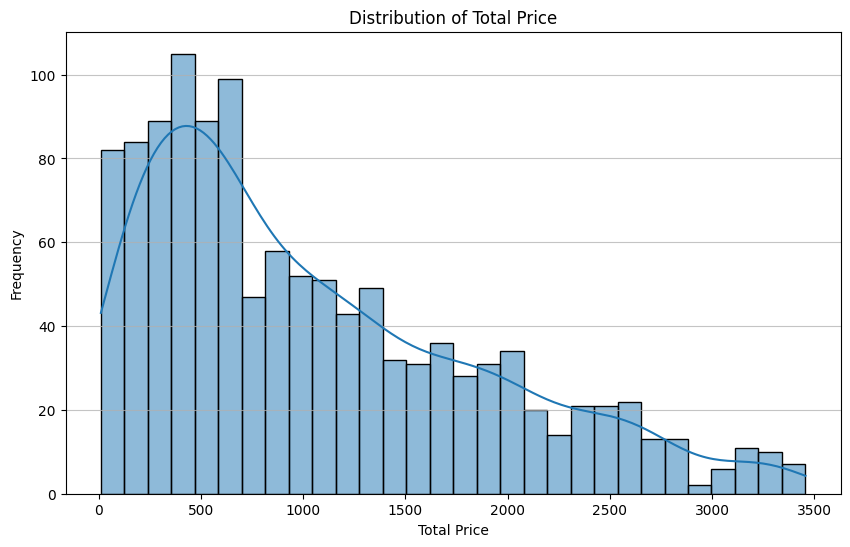

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalPrice'], bins=30, kde=True)
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Outlier Detection for TotalPrice

Let's use a boxplot to identify potential outliers in the `TotalPrice` column.

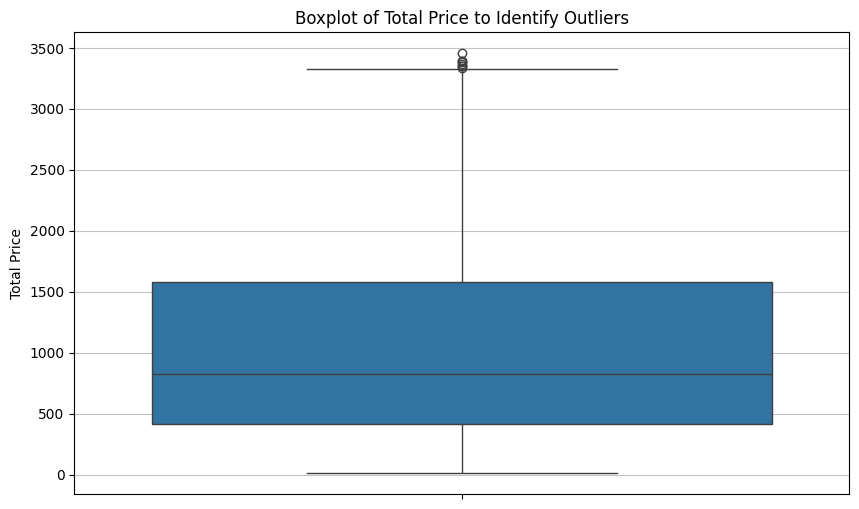

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['TotalPrice'])
plt.title('Boxplot of Total Price to Identify Outliers')
plt.ylabel('Total Price')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Quantifying Outliers: Mean and Median of TotalPrice

Let's calculate the mean and median of the `TotalPrice` to understand its central tendency and the impact of outliers.

In [ ]:
mean_total_price = df['TotalPrice'].mean()
median_total_price = df['TotalPrice'].median()

print(f"Mean of TotalPrice: {mean_total_price:.2f}")
print(f"Median of TotalPrice: {median_total_price:.2f}")

Mean of TotalPrice: 1053.97
Median of TotalPrice: 823.62


### Filter by 95th Percentile of TotalPrice

Let's identify and display rows where `TotalPrice` is greater than its 95th percentile to focus on high-value transactions or potential outliers.

In [ ]:
percentile_95 = df['TotalPrice'].quantile(0.95)
print(f"95th Percentile of TotalPrice: {percentile_95:.2f}")

df_high_total_price = df[df['TotalPrice'] > percentile_95]
print(f"\nNumber of rows with TotalPrice > 95th percentile: {len(df_high_total_price)}")
display(df_high_total_price.head())

95th Percentile of TotalPrice: 2666.45

Number of rows with TotalPrice > 95th percentile: 60


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
10,ORD200010,2023-12-29,C43443,Tablet,5,625.97,333 Main St,Credit Card,Returned,TRK98859248,9,WINTER15,Instagram,3129.85
32,ORD200032,2023-05-01,C12388,Tablet,5,536.72,830 Main St,Cash,Delivered,TRK99261395,10,NaN,Email,2683.60
86,ORD200086,2024-06-19,C88205,Printer,5,643.03,447 Main St,Online,Cancelled,TRK93504166,5,FREESHIP,Referral,3215.15


### High-Value Products Analysis

Now, let's group the `df_high_total_price` DataFrame by the 'Product' column to see which items appear most frequently in these high-value orders.

In [ ]:
high_value_products = df_high_total_price['Product'].value_counts().reset_index()
high_value_products.columns = ['Product', 'Count']

print("Products frequently appearing in high-value orders:")
display(high_value_products)

Products frequently appearing in high-value orders:


,Product,Count
0,Laptop,12
1,Tablet,11
2,Printer,10
3,Monitor,9
4,Chair,7
5,Phone,7
6,Desk,4


### Visualization of High-Value Products

Let's visualize the frequency of products appearing in high-value orders using a bar chart.

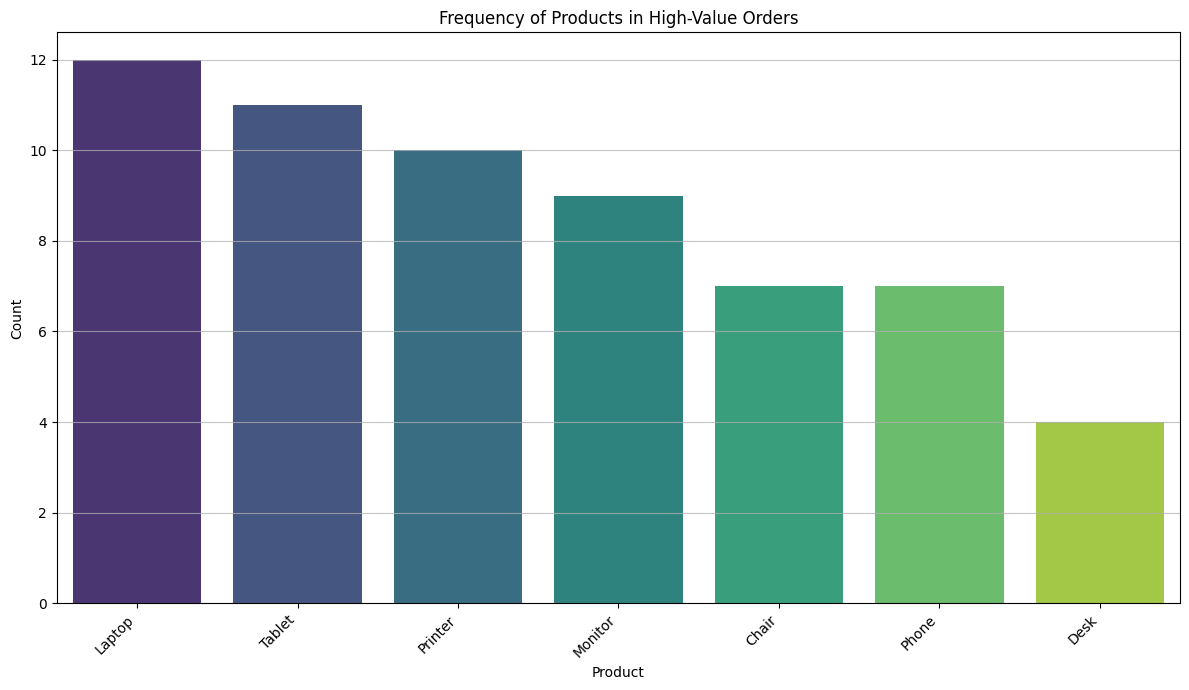

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Product', y='Count', data=high_value_products, palette='viridis')
plt.title('Frequency of Products in High-Value Orders')
plt.xlabel('Product')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Purchase Trends Over Time for Top High-Value Products

Let's analyze how the sales of our top high-value products have trended over time.

In [ ]:
# Get the list of top high-value products
top_products_list = high_value_products['Product'].tolist()
print(f"Top high-value products: {top_products_list}")

# Filter the original DataFrame for these top products
df_top_products_trends = df[df['Product'].isin(top_products_list)].copy()

Top high-value products: ['Laptop', 'Tablet', 'Printer', 'Monitor', 'Chair', 'Phone', 'Desk']


In [ ]:
# Aggregate total sales for each top product by date
product_daily_sales = df_top_products_trends.groupby(['Date', 'Product'])['TotalPrice'].sum().reset_index()

display(product_daily_sales.head())

,Date,Product,TotalPrice
0,2023-01-01,Chair,1291.70
1,2023-01-01,Monitor,729.41
2,2023-01-02,Laptop,1323.55
3,2023-01-03,Tablet,897.70
4,2023-01-04,Laptop,776.44


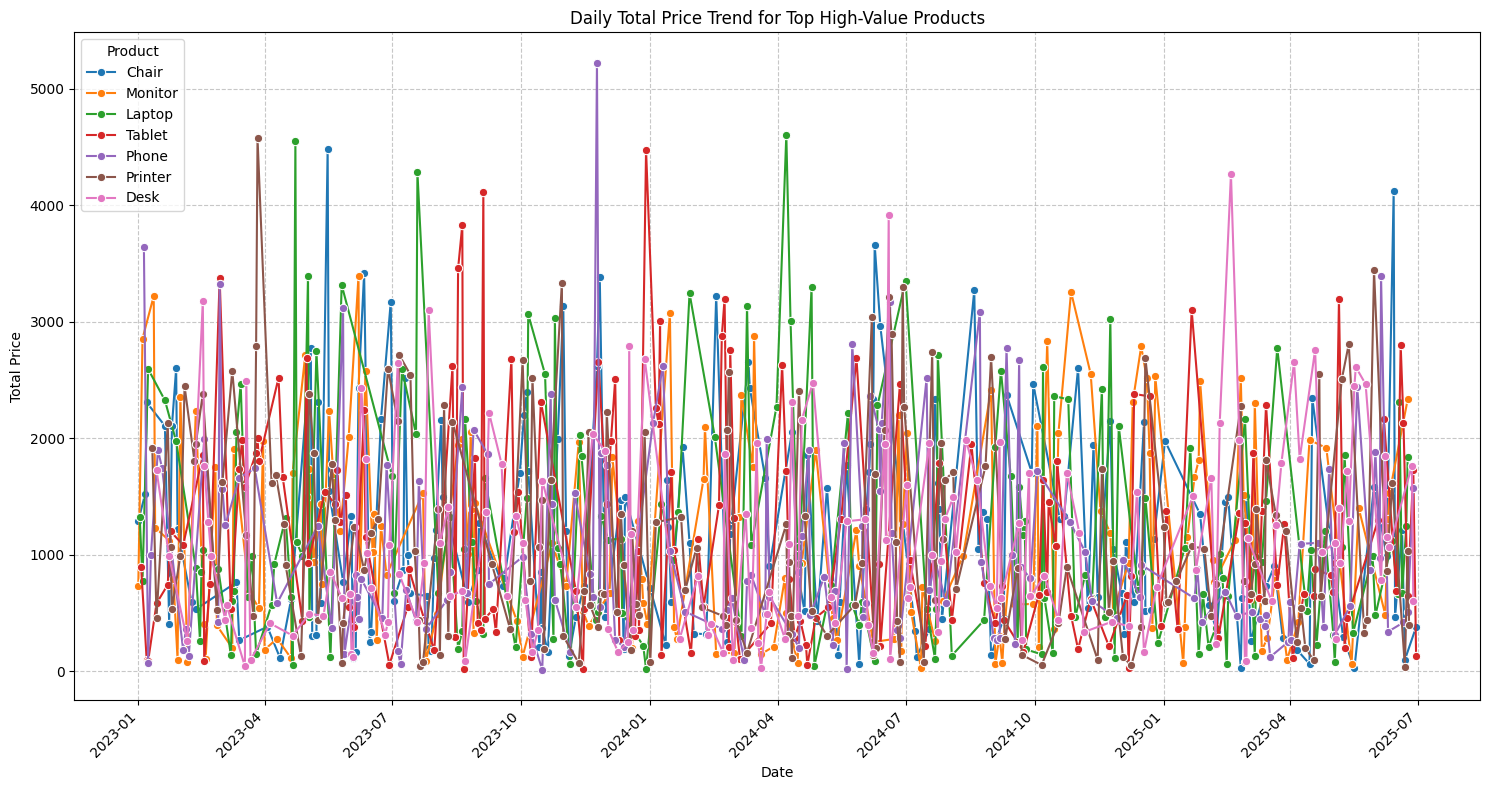

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='Date', y='TotalPrice', hue='Product', data=product_daily_sales, marker='o')
plt.title('Daily Total Price Trend for Top High-Value Products')
plt.xlabel('Date')
plt.ylabel('Total Price')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Product')
plt.tight_layout()
plt.show()